# Phase Corection
### General Story:
We got the phase and magnitude of an averaged signal from Phase on the Fly, now we want to detect frequency for PLL locking. In our case what we want is to detect the frequency difference from our expected and change to match that

We are assuming that the register is giving us an average of the entire adc read such that:
$$tan^{-1}(\frac{I}{Q}) = tan^{-1}(\frac{\int cos(\omega t + \phi)}{\int cos(\omega t + \phi + \frac{\pi}{4})})$$

Where by using some math and trig identities you get:

$$tan^{-1}(\frac{cos(\omega t + \phi)}{cos(\omega t + \phi + \frac{\pi}{4})}) = \phi$$

considering that 
$$\omega = \frac{\Delta \phi}{\Delta t}$$

we need two values of $\phi$ and the starting or stopping points of our read

In [2]:
#imports
from qick import *
from qick.asm_v2 import *
%matplotlib inline
import matplotlib.pyplot as plt
import os
import git  # pip install gitpython


In [3]:
#this block is for running a command on the RFsoC assuming you are 
#running one of the jupyter notebooks on the device but from a separate computer/visual studio code:

dir = os.getcwd()
print(dir)
print(os.listdir())
# print(os.getcwd())
# os.system("pip install gitpython")

/home/xilinx/jupyter_notebooks
['qick', 'user_implementation', 'getting_started', 'common', 'amo_qick', '.ipynb_checkpoints', 'Welcome to Pynq.ipynb']


In [4]:
#this will pull from the github to make sure you have the most current updates

import git  # pip install gitpython
print(os.listdir())
if 'amo_qick' in os.listdir():
        print("getting into fork")
        os.chdir('amo_qick')
dir = os.getcwd()
print(dir)
g = git.cmd.Git(dir)
g.pull()

['qick', 'user_implementation', 'getting_started', 'common', 'amo_qick', '.ipynb_checkpoints', 'Welcome to Pynq.ipynb']
getting into fork
/home/xilinx/jupyter_notebooks/amo_qick


'Updating c3ddbd7..f9004f0\nFast-forward\n tests/Phase_Correction.ipynb | 958 ++++++++++++++++++++++++++++++++++++++++---\n 1 file changed, 896 insertions(+), 62 deletions(-)'

In [425]:


#This line is to sync to an external clock which needs to be 10 Mhz
#this line currently loads tproc1 firmware and is just to make sure everything is loaded properly
#soc = QickSoc(external_clk=True)

dir = os.getcwd()
print(dir)
#this line downloads the new hardware (just make sure thats what you want)
#soc = QickSoc()
#soc = QickSoc(bitfile =f'{dir}/tests/d_1.bit', download=True)
#as of Jan 2026: 
#rfsoc_board = most recently published bit, 
# ADC_0 = Self built file that connects adc port 0 to tproc 1
# d_1 = self built that puts a cordic loop on adc port 0 for phase analysis 
soc = QickSoc(bitfile =f'{dir}/tests/rf_board_firmware/d_1.bit', download=True)
soccfg = soc
print(soccfg)


/home/xilinx/jupyter_notebooks/amo_qick
QICK running on ZCU216, software version 0.2.388

Firmware configuration (built Fri Apr  3 16:28:09 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 1, ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 2 is 2_228 on JHC1, o

#### Uncorrected from Laser

  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: -35.99481111939961
buffered readout: [ 6908. -5018.]
feedback readout: [      9890 -515501987]


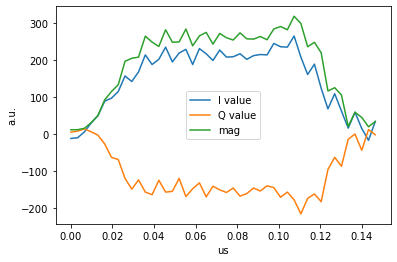

In [552]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.wait_auto(gens = True)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(ros = True)
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': .965,
          'read_wait': 0.1,
          'ro_len': .15,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# while True:
iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

### Uncorrected reference from different RF port
This isnt technically perfect but a good starting spot to see if we can correct to a specific phase value


  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: 20.76454977647431
buffered readout: [4932. 1870.]
feedback readout: [4932 1870]


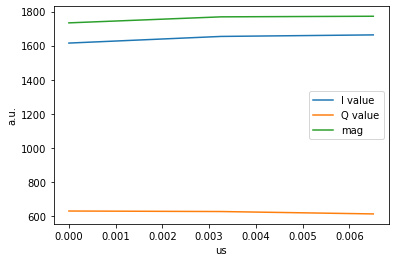

In [146]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 1,
          'ro_ch': 0,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 0.45,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

Lets see if we can correct to a static phase value. The following code is naive and should take forever to run. This is because of phase wrap around along with very small step sizes

In [8]:
objective = 0
step = 500
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)

        self.add_reg('step_size', None, QickParam(5))
        self.add_reg('neg_step_size', None, QickParam(-5))
        self.add_reg('threshold', None, QickParam(100000))

        
    def _body(self, cfg):
        
        
        
        self.label('beginning')
        #check and see if we have achieved phase = 0?
        
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        
        self.read_and_jump(cfg['ro_ch'],'Q', 0,'<', 'add')
        self.jump('sub')


        self.label('add')
        self.inc_reg('w_phase', 'step_size')
        self.cond_jump('finish', 's_port_h','NS', '+','threshold')
        self.jump('beginning')

        self.label('sub')
        self.inc_reg('w_phase', 'neg_step_size')
        self.cond_jump('finish', 's_port_h','S', '-','threshold')
        self.jump('beginning')

        self.label('finish')


config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
#print(prog)
iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

#### ok naive doesn't work
Lets try to actually get a test here that provides something useful. First I will start with what the graph looks like if I sweep the phase from its most negative to most positive value

In [ ]:
def phase_change(phase_range=(100,110), phase_division = 10, num_reps = 10):
    class ReadProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            ro_ch = cfg['ro_ch']
            gen_ch = cfg['gen_ch']
            
            self.declare_gen(ch=gen_ch, nqz=1)
            self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

            self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                        style="const", 
                        freq=cfg['freq'], 
                        length=cfg['pulse_len'],
                        phase=cfg['pulse_phase'],
                        gain=cfg['gain'], 
                        )

            self.add_readoutconfig(ch=ro_ch, name="myro", freq=config['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
            # send the config to the dynamic RO
            self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
            
        def _body(self, cfg):
            self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
            self.wait_auto(cfg['read_wait'])
            self.read_input(ro_ch=cfg['ro_ch'])
            self.write_dmem(addr=0, src='s_port_l')
            self.write_dmem(addr=1, src='s_port_h')

    

    # prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
    # iq_list = prog.acquire(soc, rounds=1, progress=False)
    # phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
    # config['ro_phase'] = -phase_offset
    plt.figure()
    phase_span = np.linspace(phase_range[0], phase_range[1], phase_division)
    phasebyphase = []
    for i, phase in enumerate(phase_span):
        config = {'gen_ch': 1,
            'ro_ch': 0,
            'freq': 120,
            'trig_time': 0.40,
            'read_wait': 0.1,
            'ro_len': 0.1,
            'pulse_len': 0.025,
            'pulse_phase':phase,
            'ro_phase': 0,
            'gain': 0.5
            }
        phase_data = []
        for rep in range(num_reps):
            prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

            iq_list = prog.acquire_decimated(soc, progress = False, rounds=1)
            t = prog.get_time_axis(ro_index=0)

            phase_maybe = soc.read_mem(2,'dmem')
            
            mag = phase_maybe[0]
            phase_dif = phase_maybe[1]

            phase_data.append((phase_dif, mag))
            
        phasebyphase.append(phase_data)
    return phasebyphase
phase_range = (-180,180)
phase_division = 21
phasebyphase = phase_change(phase_range=phase_range, phase_division= 21, num_reps=300)

KeyboardInterrupt: 

<Figure size 432x288 with 0 Axes>

6330


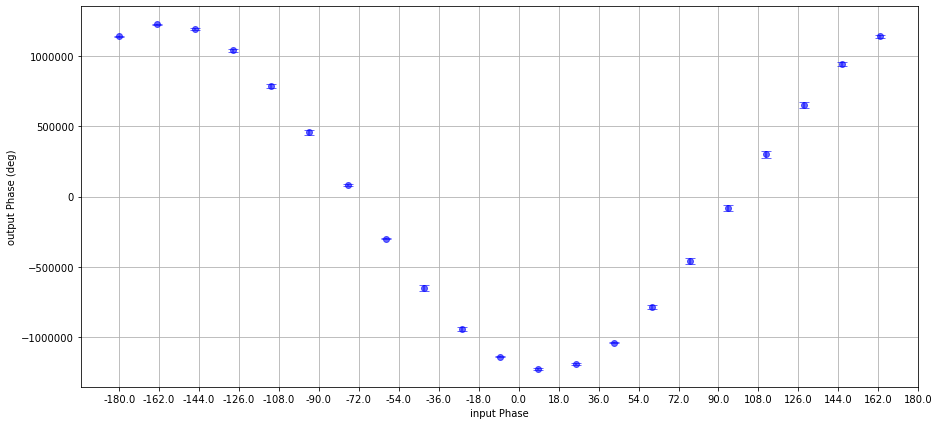

In [ ]:

plt.figure(figsize = (15,7))

# Assuming phasebyphase is a list of arrays or lists, each with shape (N, 2)
print(phasebyphase[0][0][0])
for idx, phase_vals in enumerate(phasebyphase):

    phase_vals = np.asarray(phase_vals)
    value = phase_vals[:, 0]*180

    mean_val = np.mean(value)
    std_val = np.std(value)

    # Plot mean with error bar (std deviation)
    plt.errorbar(idx, mean_val, yerr=std_val, fmt='o', alpha=0.6, capsize=5, color='blue')

# Set x-ticks to correspond to phases
phases = np.linspace(phase_range[0], phase_range[1], len(phasebyphase))
plt.xticks(np.linspace(0,21,21), phases)
plt.ylabel("output Phase (deg)")
plt.xlabel("input Phase")
plt.grid(True)
#plt.title("Phase Error by Frequency")


What I will do first is correct the phase of the RF reference to assure my looping algorithm is reasonable

  0%|          | 0/1 [00:00<?, ?it/s]

feedback readout: [ 1685 -6602]


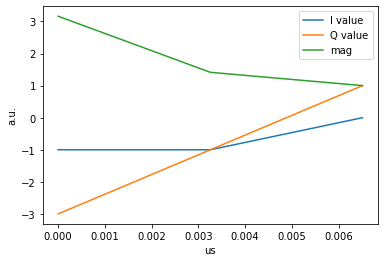

In [148]:
objective = 0
step = 500
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)

        self.add_reg('step_size', None, QickParam(5))
        self.add_reg('neg_step_size', None, QickParam(-5))
        self.add_reg('threshold', None, QickParam(5))

        
    def _body(self, cfg):
        
        
        
        self.label('beginning')
        #check and see if we have achieved phase = 0?
        
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        
        self.read_and_jump(cfg['ro_ch'],'Q', 0,'<', 'add')
        self.jump('sub')


        self.label('add')
        self.inc_reg('w_phase', 'step_size')
        self.cond_jump('finish', 's_port_h','NS', '+','threshold')
        self.jump('beginning')

        self.label('sub')
        self.inc_reg('w_phase', 'neg_step_size')
        self.cond_jump('finish', 's_port_h','S', '-','threshold')
        self.jump('beginning')

        self.label('finish')


config = {'gen_ch': 1,
          'ro_ch': 0,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
#print(prog)
iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
# print("phase offset:", phase_offset)

# print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

Seems to know when its locked to zero phase so lets see if we can add it back to the laser data and get it to lock

In [ ]:
def phase_change(phase_range=(100,110), phase_division = 10, num_reps = 10):
    class ReadProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            ro_ch = cfg['ro_ch']
            gen_ch = cfg['gen_ch']
            
            self.declare_gen(ch=gen_ch, nqz=1)
            self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

            self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                        style="const", 
                        freq=cfg['freq'], 
                        length=cfg['pulse_len'],
                        phase=cfg['pulse_phase'],
                        gain=cfg['gain'], 
                        )

            self.add_readoutconfig(ch=ro_ch, name="myro", freq=config['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
            # send the config to the dynamic RO
            self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
            
        def _body(self, cfg):
            self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
            self.wait_auto(cfg['read_wait'])
            self.read_input(ro_ch=cfg['ro_ch'])
            self.write_dmem(addr=0, src='s_port_l')
            self.write_dmem(addr=1, src='s_port_h')

    

    # prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
    # iq_list = prog.acquire(soc, rounds=1, progress=False)
    # phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
    # config['ro_phase'] = -phase_offset
    plt.figure()
    phase_span = np.linspace(phase_range[0], phase_range[1], phase_division)
    phasebyphase = []
    for i, phase in enumerate(phase_span):
        config = {'gen_ch': 0,
            'ro_ch': 10,
            'freq': 120,
            'trig_time': 1,
            'read_wait': 0.1,
            'ro_len': 0.1,
            'pulse_len': 0.025,
            'pulse_phase':phase,
            'ro_phase': 0,
            'gain': 0.5
            }
        phase_data = []
        for rep in range(num_reps):
            prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

            iq_list = prog.acquire_decimated(soc, progress = False, rounds=1)
            t = prog.get_time_axis(ro_index=0)

            phase_maybe = soc.read_mem(2,'dmem')
            
            mag = phase_maybe[0]
            phase_dif = phase_maybe[1]

            phase_data.append((phase_dif, mag))
            
        phasebyphase.append(phase_data)
    return phasebyphase
phase_range = (-180,180)
phase_division = 21
phasebyphase = phase_change(phase_range=phase_range, phase_division= 21, num_reps=300)

<Figure size 432x288 with 0 Axes>

1263179494


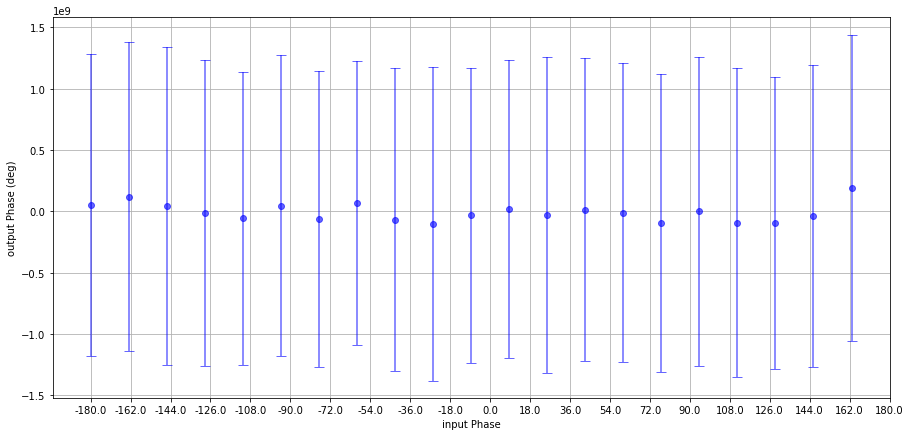

In [ ]:

plt.figure(figsize = (15,7))

# Assuming phasebyphase is a list of arrays or lists, each with shape (N, 2)
print(phasebyphase[0][0][0])
for idx, phase_vals in enumerate(phasebyphase):

    phase_vals = np.asarray(phase_vals)
    value = phase_vals[:, 0]*180

    mean_val = np.mean(value)
    std_val = np.std(value)

    # Plot mean with error bar (std deviation)
    plt.errorbar(idx, mean_val, yerr=std_val, fmt='o', alpha=0.6, capsize=5, color='blue')

# Set x-ticks to correspond to phases
phases = np.linspace(phase_range[0], phase_range[1], len(phasebyphase))
plt.xticks(np.linspace(0,21,21), phases)
plt.ylabel("output Phase (deg)")
plt.xlabel("input Phase")
plt.grid(True)
#plt.title("Phase Error by Frequency")


We want to make an algorithm that makes the above graph look closer to our reference graph. First I would like to know how the phase changes in a specific pulse

  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: -85.15710357707992
buffered readout: [  370. -4367.]
feedback readout: [    12054 255568806]


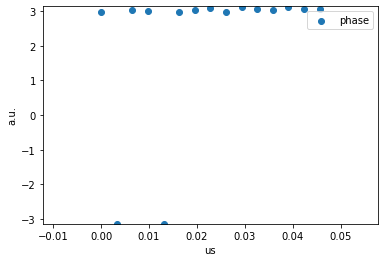

In [149]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .05,
          'pulse_len': 0.1,
          'pulse_phase': 170,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.scatter(t, np.arctan2(iq_list[0][:,0], iq_list[0][:,1]), label="phase")
# plt.plot(t, iq_list[0][:,1], label="Q value")
# plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");
plt.ylim(-3.14, 3.14)

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

  0%|          | 0/1 [00:00<?, ?it/s]

No handles with labels found to put in legend.


buffered readout: [[[ 1.133e+03  4.531e+03]
  [ 8.230e+02  5.048e+03]
  [ 1.331e+03  5.112e+03]
  [ 1.041e+03  4.626e+03]
  [ 8.330e+02  5.151e+03]
  [ 1.346e+03  4.937e+03]
  [ 9.020e+02  4.687e+03]
  [ 1.087e+03  5.106e+03]
  [ 1.277e+03  4.760e+03]
  [ 9.560e+02  4.891e+03]
  [ 1.259e+03  4.996e+03]
  [ 1.176e+03  4.752e+03]
  [ 1.085e+03  4.947e+03]
  [ 1.275e+03  4.938e+03]
  [ 1.125e+03  4.780e+03]
  [ 1.057e+03  4.939e+03]
  [ 9.810e+02  4.935e+03]
  [ 7.210e+02  5.123e+03]
  [ 1.012e+03  5.517e+03]
  [ 1.213e+03  5.413e+03]
  [ 1.189e+03  5.698e+03]
  [ 2.044e+03  5.793e+03]
  [ 2.525e+03  4.717e+03]
  [ 1.996e+03  4.267e+03]
  [ 2.313e+03  4.092e+03]
  [ 2.151e+03  2.602e+03]
  [ 7.500e+02  2.141e+03]
  [ 7.790e+02  2.273e+03]
  [ 7.310e+02  1.051e+03]
  [-2.780e+02  7.490e+02]
  [ 1.070e+02  9.990e+02]]

 [[ 6.000e+00 -6.000e+00]
  [-9.000e+00 -1.000e+00]
  [ 3.000e+00  2.000e+00]
  [-3.000e+00  5.000e+00]
  [-2.000e+00  2.000e+00]
  [-1.000e+00  2.000e+00]
  [ 7.000e+00  9.0

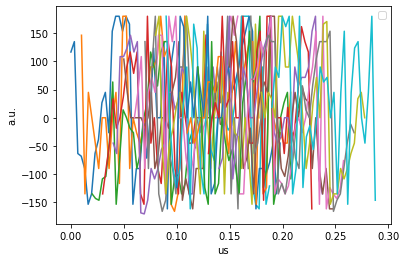

In [ ]:
threshold = 1

class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)

        setpoint = self.add_reg('setpoint', None, QickParam(0))
        kp = self.add_reg('kp', None, QickParam(2)) #this will be a bit move by 2 so equivalent to >>2 or kp = 0.25
        measure = self.add_reg('measure') #have to save from s_port_h
        error = self.add_reg('error')
        self.add_reg('threshold', None, QickParam(threshold))

    def return_addr(self, reg:str):
        """
        Given a register returns the address assigned to it (im using it for asm_inst)
        """
        try:
            # is name of register?
            reg = self.reg_dict[reg].full_addr()
        except:
            pass
        return reg
    def add(self, rd, rs1, rs2):
        '''copying the structure of RISCV to help myself out'''
        reg_dest = self.return_addr(rd)
        reg_src1 = self.return_addr(rs1)
        reg_src2 = self.return_addr(rs2)
        self.asm_inst({'CMD': 'REG_WR', 'DST': f'{reg_dest}', 'SRC': 'op', 'OP':f'{reg_src1} + {reg_src2}'})
    def addi(self, rd, rs1, imm):
        '''copying the structure of RISCV to help myself out'''
        reg_dest = self.return_addr(rd)
        reg_src1 = self.return_addr(rs1)
        self.asm_inst({'CMD': 'REG_WR', 'DST': f'{reg_dest}', 'SRC': 'op', 'OP':f'{reg_src1} + {imm}'})   
    def sub(self, rd, rs1, rs2):
        '''copying the structure of RISCV to help myself out'''
        reg_dest = self.return_addr(rd)
        reg_src1 = self.return_addr(rs1)
        reg_src2 = self.return_addr(rs2)
        self.asm_inst({'CMD': 'REG_WR', 'DST': f'{reg_dest}', 'SRC': 'op', 'OP':f'{reg_src1} - {reg_src2}'})
    def srli(self, rd, rs1 ,imm):
        '''copying the structure of RISCV to help myself out'''
        reg_dest = self.return_addr(rd)
        reg_src1 = self.return_addr(rs1)
        self.asm_inst({'CMD': 'REG_WR', 'DST': f'{reg_dest}', 'SRC': 'op', 'OP':f'{reg_src1} >> {imm}'}) 
    def Kp_error(self, Kp_reg, set_reg, error_reg, measure_reg):
        #This assumes that the registers have already been read/finished
        self.sub(error_reg, set_reg,measure_reg)
        self.srli(error_reg, error_reg, '#6') #same as kp=0.25
        self.add(Kp_reg, measure_reg, error_reg)
        
    def _body(self, cfg):
        
        
        self.label('beginning')
        #check and see if we have achieved phase = 0?
        
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        
        self.read_input(cfg['ro_ch'])

        self.write_dmem(addr='measure', src='s_port_h')
        self.Kp_error('kp', 'setpoint', 'error', 'measure')

        self.cond_jump('neg', 'error', 'S')
        self.jump('pos')

        self.label('neg')
        self.cond_jump('finish', 'error', 'NS', '+', 'threshold')
        self.jump('PID')
        
        self.label('pos')
        self.cond_jump('finish', 'error', 'S', '-', 'threshold')
        self.jump('PID')

        self.jump('finish')
        #Below I will try to get the error of the signal
        self.label('PID')
        self.write_reg('w_phase', 'kp')
        self.jump('beginning')

        
        
        self.label('finish')
        self.delay_auto()
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=20, final_delay=0.5, cfg=config)
#print(prog)
iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)
#print(iq_list[0])
for i, rnd in enumerate(iq_list[0]):
    buffer_phase = np.arctan2(rnd[:,:,0], rnd[:,:,1])/np.pi * 180
    avg = np.average(buffer_phase,0)
    std = np.std(buffer_phase,0)
    plt.errorbar(t+0.01*i, np.arctan2(rnd[1,:,0], rnd[1,:,1])/np.pi * 180)
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

All of this is fine-ish but in total It is hard to understand without proper understanding of a full experiment. So what we will do is trigger an ADC that records for the entire experiment and split the signal between correction and measurement

In [ ]:
threshold = 1000
force_stop = 10000000 # if there are 1000 loops just quit and show me phase of last one
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        # self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # # send the config to the dynamic RO
        # self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        self.add_reg('force', None, QickParam(force_stop))
        self.add_reg('rnd', None, QickParam(1))
        setpoint = self.add_reg('setpoint', None, QickParam(50))
        control = self.add_reg('control', None, QickParam(2)) 
        measure = self.add_reg('measure') #have to save from s_port_h
        error = self.add_reg('error')
        self.add_reg('threshold', None, QickParam(threshold))
        self.add_reg('stability', None, QickParam(0)) #determines the number of loops to decide of the thing is stable
        self.add_reg('zero', None, QickParam(0))
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)

    def return_addr(self, reg:str):
        """
        Given a register returns the address assigned to it (im using it for asm_inst)
        """
        try:
            # is name of register?
            reg = self.reg_dict[reg].full_addr()
        except:
            pass
        return reg
    def add(self, rd, rs1, rs2):
        '''copying the structure of RISCV to help myself out'''
        reg_dest = self.return_addr(rd)
        reg_src1 = self.return_addr(rs1)
        reg_src2 = self.return_addr(rs2)
        self.asm_inst({'CMD': 'REG_WR', 'DST': f'{reg_dest}', 'SRC': 'op', 'OP':f'{reg_src1} + {reg_src2}'})
    def addi(self, rd, rs1, imm):
        '''copying the structure of RISCV to help myself out'''
        reg_dest = self.return_addr(rd)
        reg_src1 = self.return_addr(rs1)
        self.asm_inst({'CMD': 'REG_WR', 'DST': f'{reg_dest}', 'SRC': 'op', 'OP':f'{reg_src1} + {imm}'})   
    def sub(self, rd, rs1, rs2):
        '''copying the structure of RISCV to help myself out'''
        reg_dest = self.return_addr(rd)
        reg_src1 = self.return_addr(rs1)
        reg_src2 = self.return_addr(rs2)
        self.asm_inst({'CMD': 'REG_WR', 'DST': f'{reg_dest}', 'SRC': 'op', 'OP':f'{reg_src1} - {reg_src2}'})
    def srli(self, rd, rs1 ,imm):
        '''copying the structure of RISCV to help myself out'''
        reg_dest = self.return_addr(rd)
        reg_src1 = self.return_addr(rs1)
        self.asm_inst({'CMD': 'REG_WR', 'DST': f'{reg_dest}', 'SRC': 'op', 'OP':f'{reg_src1} >> {imm}'}) 
    def Kp_error(self, control_reg, set_reg, error_reg, measure_reg, kp:int):
        #This assumes that the registers have already been read/finished
        #get the signed error
        self.sub(error_reg, set_reg, measure_reg)
        #treat signs differently
        self.cond_jump('neg', error_reg, 'S')

        #error is positive
        self.cond_jump('finish', error_reg, 'S', '-', 'threshold')
        self.srli(error_reg, error_reg, f'#{kp}')
        self.jump('change_cntrl')


        #error is negative
        self.label('neg')
        self.sub(error_reg, 'zero', error_reg)
        self.cond_jump('finish', error_reg, 'S', '-', 'threshold')
        self.srli(error_reg, error_reg, f'#{kp}')
        self.sub(error_reg, 'zero', error_reg)
        self.jump('change_cntrl')
        


        self.label('change_cntrl')
        self.add(control_reg, control_reg, error_reg)



        
        
    def _body(self, cfg):
        self.label('beginning')

        # 1. Trigger FIRST to open the readout window
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=0)

        # 2. Pulse after trigger, offset by trig_time so signal
        #    arrives inside the open window
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=cfg['trig_time'])

        # 3. Wait for the readout window to fully close
        self.wait_auto(ros=True)

        # 4. NOW read — accumulator has exactly one shot
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_reg('measure', 's_port_h')


        self.inc_reg('force', -1)
        self.cond_jump('exit', 'force', 'S', '-', 1)

        self.Kp_error('control', 'setpoint', 'error', 'measure', kp=4)

        self.write_reg('w_phase', 'control')
        self.write_reg('stability', 'zero')
        self.jump('beginning')      

        self.label('finish')
        self.inc_reg('stability', 1)
        

        # Require 2 consecutive stable reads.
        self.cond_jump('beginning', 'stability', 'S', '-', 3)

        self.label('exit')
        self.wait_auto(gens=True, ros=True)
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')
        self.write_dmem(addr=2, src='control')
        self.write_dmem(addr=3, src='error')
        self.write_dmem(addr=4, src='stability')
        self.write_dmem(addr=5, src='force')


config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': .965,
          'read_wait': 0.1,
          'ro_len': .1,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
#print(prog)
iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)
#print(iq_list[0])



  0%|          | 0/1 [00:00<?, ?it/s]

No handles with labels found to put in legend.


buffered readout: [5. 1.]
feedback readout: [        24 -154838338]
error:  [9677399]
forced to stop?  True


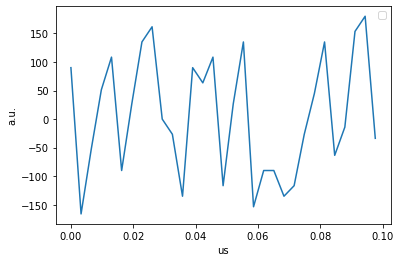

In [619]:
for i, rnd in enumerate(iq_list):
    
    buffer_phase = np.arctan2(rnd[:,0], rnd[:,1])/np.pi * 180
    buffer_mag = np.abs(rnd.dot([1,1j]))
    plt.errorbar(t, buffer_phase)

plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))
print("error: ", soc.read_mem(1, 'dmem', addr=3))
print("forced to stop? ", soc.read_mem(1, 'dmem', addr=5)[0]==0)

phase offset: 11.309932474020213
buffered readout: [5. 1.]
feedback readout: [        24 -154838338]


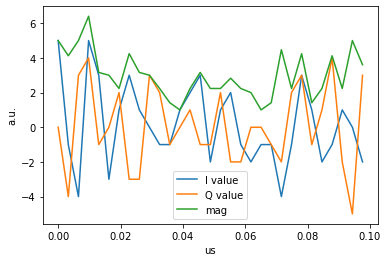

In [620]:
plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))